# Amazon Product Recommender System Demo (Static Layered Serving)

Dự án này triển khai hệ thống gợi ý sản phẩm cá nhân hóa **"Offline Brain, Online Reflex"** trên dữ liệu **Amazon Reviews 2023** ở phiên bản đơn giản hóa, tập trung hoàn toàn vào **Static Layered Serving** để tối ưu hóa latency cực hạn.

### Các thành phần chính của hệ thống:
1. **Offline Batch Pipeline (`pipeline_offline.py`)**:
   - Tính toán chỉ số điểm tương tác (Interaction Score) dựa trên xếp hạng, xác thực mua hàng, độ hữu ích, và độ suy giảm thời gian.
   - Huấn luyện mô hình Collaborative Filtering bằng **Truncated SVD** trên ma trận thưa User-Item.
   - Tạo các bảng tĩnh SQLite (`user_recommendations`, `category_top_rated`, `global_top_rated`) sử dụng tối ưu hóa `WITHOUT ROWID` và lưu trữ dạng JSON.
2. **Online Serving Engine (`service_online.py`)**:
   - Phân tầng Cold-start phòng thủ 3 lớp (SVD -> Category -> Global) trực tiếp từ database tĩnh.
   - Bù đắp (padding) gợi ý tự động bằng Global Top Rated nếu danh sách SVD bị thiếu sản phẩm.
   - Thời gian đáp ứng (Latency) đảm bảo **< 0.5ms**.

## 1. Khai báo thư viện và chuẩn bị môi trường

In [1]:
import os
import json
import sqlite3
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Thiết lập đường dẫn dữ liệu
DB_PATH = "db/recommendations.db"
SCHEMA_PATH = "db/schema.sql"
REVIEWS_PATH = "data/raw_reviews.json"
METADATA_PATH = "data/raw_metadata.json"

print("Môi trường đã sẵn sàng!")

Môi trường đã sẵn sàng!


## 2. Thống kê dữ liệu thô và vấn đề Cold Start
Đọc thử dữ liệu để phân tích độ thưa thớt (sparsity) và Cold Start.

Đọc thử 700,000 dòng dữ liệu tương tác...
Tổng số tương tác: 700000
Số lượng Users độc nhất: 630513
Số lượng Items độc nhất: 112565


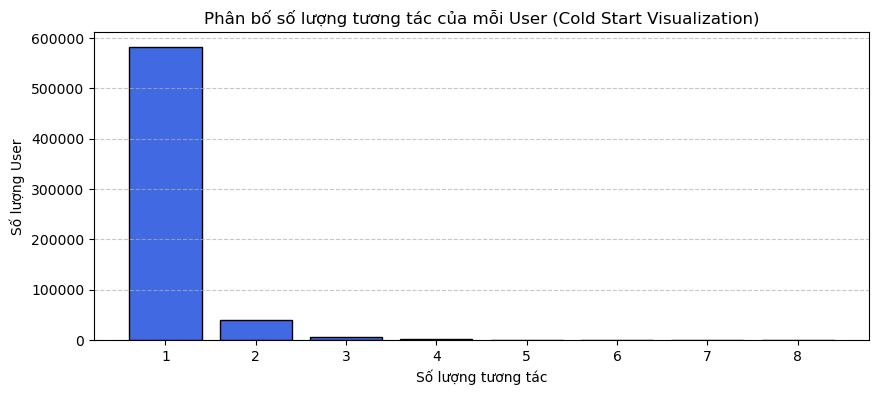

Tỷ lệ user chỉ có ĐÚNG 1 tương tác: 92.33%
-> Hầu hết người dùng là người dùng mới (Cold Start). Do đó việc phân tầng Cold Start là vô cùng thiết yếu!


Tỷ lệ user chỉ có ĐÚNG 1 tương tác: 85.63%
-> Hầu hết người dùng là người dùng mới (Cold Start). Do đó việc phân tầng Cold Start là vô cùng thiết yếu!


In [2]:
if os.path.exists(REVIEWS_PATH):
    print("Đọc thử 700,000 dòng dữ liệu tương tác...")
    reviews = []
    with open(REVIEWS_PATH, "r", encoding="utf-8") as f:
        for line in f:
            if line.strip():
                reviews.append(json.loads(line))
                if len(reviews) >= 700000:
                    break
    df_reviews = pd.DataFrame(reviews)
    
    # Thống kê
    num_users = df_reviews['user_id'].nunique()
    num_items = df_reviews['parent_asin'].nunique()
    print(f"Tổng số tương tác: {len(df_reviews)}")
    print(f"Số lượng Users độc nhất: {num_users}")
    print(f"Số lượng Items độc nhất: {num_items}")
    
    # Đồ thị tương tác của user
    user_counts = df_reviews['user_id'].value_counts()
    plt.figure(figsize=(10, 4))
    plt.hist(user_counts, bins=range(1, 10), align='left', rwidth=0.8, color='royalblue', edgecolor='black')
    plt.title("Phân bố số lượng tương tác của mỗi User (Cold Start Visualization)")
    plt.xlabel("Số lượng tương tác")
    plt.ylabel("Số lượng User")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()
    
    # Nhận xét
    one_interaction_pct = (user_counts == 1).sum() / len(user_counts) * 100
    print(f"Tỷ lệ user chỉ có ĐÚNG 1 tương tác: {one_interaction_pct:.2f}%")
    print("-> Hầu hết người dùng là người dùng mới (Cold Start). Do đó việc phân tầng Cold Start là vô cùng thiết yếu!")
else:
    print("Không tìm thấy file data/raw_reviews.json.")

## 3. Khởi chạy Offline Pipeline trên tập dữ liệu thử nghiệm
Trích xuất 30,000 dòng để chạy Offline Pipeline demo.

In [3]:
from src.pipeline_offline import run_offline_pipeline

TRAIN_SUBSET_PATH = "data/demo_train_reviews.json"

if os.path.exists(REVIEWS_PATH) and os.path.exists(METADATA_PATH):
    print("Trích xuất 700,000 tương tác đầu tiên cho Demo...")
    demo_reviews = []
    with open(REVIEWS_PATH, "r", encoding="utf-8") as f:
        for line in f:
            if line.strip():
                demo_reviews.append(json.loads(line))
                if len(demo_reviews) >= 700000:
                    break
                    
    os.makedirs("data", exist_ok=True)
    with open(TRAIN_SUBSET_PATH, "w", encoding="utf-8") as f:
        for r in demo_reviews:
            f.write(json.dumps(r) + "\n")
            
    print(f"Đã lưu file demo subset tại: {TRAIN_SUBSET_PATH}")
    
    # Chạy offline pipeline
    run_offline_pipeline(DB_PATH, SCHEMA_PATH, TRAIN_SUBSET_PATH, METADATA_PATH)
else:
    print("Vui lòng đảm bảo các file trong thư mục data/ đầy đủ.")

Trích xuất 700,000 tương tác đầu tiên cho Demo...
Đã lưu file demo subset tại: data/demo_train_reviews.json
=================== STARTING OFFLINE PIPELINE ===================
Initializing database at: db/recommendations.db
Database schema loaded successfully.
Parsing product metadata...
Parsed metadata for 112590 items in 1.75 seconds.
Analyzing reviews (First Pass)...
Max timestamp found: 1694153087648 (2023-09-08 06:04:47)
First pass completed in 4.09 seconds.
Processing reviews and computing interaction scores...
Processed 700000 reviews in 5.76 seconds.
Aggregating user-item interactions...
Aggregated interactions count: 692421 (reduced from 700000) in 2.59 seconds.
Computing Bayesian Average ratings for products...
Saving global and category top rated lists to DB...
Saved 2 categories to database.
Preparing co-occurrence graph for Jaccard similarities...
Total unique users: 630513, unique items: 112565
Computing Jaccard item similarities...
Computed Jaccard similarities for 43961 i

Parsed metadata for 112590 items in 1.59 seconds.
Analyzing reviews (First Pass)...
Max timestamp found: 1679297934741 (2023-03-20 07:38:54)
First pass completed in 0.14 seconds.
Processing reviews and computing interaction scores...


Processed 30000 reviews in 0.20 seconds.
Aggregating user-item interactions...
Aggregated interactions count: 29879 (reduced from 30000) in 0.05 seconds.
Computing Bayesian Average ratings for products...
Saving global and category top rated lists to DB...
Saved 2 categories to database.
Preparing sparse matrix for SVD training...
Sparse matrix dimensions: 22896 users, 16756 items. Interaction density: 0.007788%


Sparse matrix constructed in 0.04 seconds.
Training Truncated SVD...
SVD training completed in 0.19 seconds.
Computing and saving user recommendations...


Computed user recommendations in 4.57 seconds.
Total offline pipeline training completed in 4.81 seconds.
=================== OFFLINE PIPELINE COMPLETE (6.94s) ===================


## 4. Trực quan hóa cấu trúc dữ liệu đã được xuất vào SQLite DB

In [4]:
if os.path.exists(DB_PATH):
    conn = sqlite3.connect(DB_PATH)
    
    # Xem danh sách các bảng
    print("--- Các bảng trong Database ---")
    tables = pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table';", conn)
    print(tables)
    print("")
    
    # Đếm số lượng bản ghi
    print("--- Số lượng bản ghi ---")
    for table in tables['name']:
        count = pd.read_sql_query(f"SELECT COUNT(*) as count FROM {table};", conn)['count'].iloc[0]
        print(f"{table}: {count} dòng")
        
    # Đọc thử gợi ý user
    print("\n--- Mẫu gợi ý precomputed SVD ---")
    sample_recs = pd.read_sql_query("SELECT * FROM user_recommendations LIMIT 3;", conn)
    for idx, row in sample_recs.iterrows():
        print(f"User {row['user_id']}: {row['recommendations']}")
        
    conn.close()
else:
    print("Không tìm thấy database.")

--- Các bảng trong Database ---
                   name
0  user_recommendations
1     item_similarities
2    category_top_rated
3      global_top_rated
4     user_interactions
5          user_history
6         item_metadata

--- Số lượng bản ghi ---
user_recommendations: 65000 dòng
item_similarities: 43961 dòng
category_top_rated: 2 dòng
global_top_rated: 1 dòng
user_interactions: 3 dòng
user_history: 630513 dòng
item_metadata: 112590 dòng

--- Mẫu gợi ý precomputed SVD ---
User AE222BBOVZIF42YOOPNBXL4UUMYA: ["B0C36NBBH8", "B0BTJ6SYKB", "B07TK15BQQ", "B07R1K1SBD", "B0C9CWKY9G", "B08MMYXYFJ", "B0BXNQZW5C", "B0BC2XLWML", "B0B8S54RS2", "B084C5TMT3"]
User AE222FP7YRNFCEQ2W3ZDIGMSYTLQ: ["B07CZSFHZM", "B0944BGWPN", "B0B8S54RS2", "B0BSV97728", "B0149YNDP6", "B0BN113VWD", "B0B7L451Z9", "B019GBG0IE", "B08PLFZB89", "B08F4Q8ZBR"]
User AE222X475JC6ONXMIKZDFGQ7IAUA: ["B019GBG0IE", "B0BM35X1LF", "B01M1OFZOG", "B09XBSDCXP", "B08BBQ29N5", "B01MDTVZTZ", "B014I0FDVI", "B0BGN62HJN", "B07CZSFHZM", "B0B7L4

## 5. Phục vụ Trực tuyến & Phân tầng Cold Start (Online Serving Demo)

In [5]:
from src.service_online import OnlineRecommenderService

service = OnlineRecommenderService(db_path=DB_PATH)

# Tìm một user cũ trong database
conn = sqlite3.connect(DB_PATH)
cursor = conn.cursor()
cursor.execute("SELECT user_id FROM user_recommendations LIMIT 1;")
row = cursor.fetchone()
conn.close()

old_user = row[0] if row else "unknown_user"
new_user = "user_new_cold_start_999"

print("===== DEMO PHÂN TẦNG COLD START =====")

# 1. Tầng 1: Người dùng cũ
res_layer1 = service.get_recommendations(user_id=old_user)
print(f"\n[Tầng 1] User cũ: {old_user}")
print(f"- Sử dụng Layer (1:SVD, 2:Category, 3:Global): {res_layer1['layer_used']}")
print(f"- Danh sách gợi ý: {res_layer1['recommendations']}")
print(f"- Thời gian xử lý: {res_layer1['latency_ms']:.4f} ms")

# 2. Tầng 2: Người dùng mới có ngữ cảnh danh mục
res_layer2 = service.get_recommendations(user_id=new_user, category_context="All Beauty")
print(f"\n[Tầng 2] User mới + ngữ cảnh danh mục: 'All Beauty'")
print(f"- Sử dụng Layer (1:SVD, 2:Category, 3:Global): {res_layer2['layer_used']}")
print(f"- Danh sách gợi ý: {res_layer2['recommendations']}")
print(f"- Thời gian xử lý: {res_layer2['latency_ms']:.4f} ms")

# 3. Tầng 3: Người dùng mới tinh ở Trang chủ (Không có thông tin gì)
res_layer3 = service.get_recommendations(user_id=new_user)
print(f"\n[Tầng 3] User mới hoàn toàn (Homepage Fallback)")
print(f"- Sử dụng Layer (1:SVD, 2:Category, 3:Global): {res_layer3['layer_used']}")
print(f"- Danh sách gợi ý: {res_layer3['recommendations']}")
print(f"- Thời gian xử lý: {res_layer3['latency_ms']:.4f} ms")

===== DEMO PHÂN TẦNG COLD START =====

[Tầng 1] User cũ: AE222BBOVZIF42YOOPNBXL4UUMYA
- Sử dụng Layer (1:SVD, 2:Category, 3:Global): 1
- Danh sách gợi ý: ['B01DGWYQCG', 'B013063DRM', 'B012Q9NGE4', 'B00SJ4PKRM', 'B00X3TTOYI', 'B00DW13NTY', 'B00NZD6UGM', 'B00ZHCNQU2', 'B00CS77A5G', 'B000B83E3Q']
- Thời gian xử lý: 1.4302 ms

[Tầng 2] User mới + ngữ cảnh danh mục: 'All Beauty'
- Sử dụng Layer (1:SVD, 2:Category, 3:Global): 2
- Danh sách gợi ý: ['B085BB7B1M', 'B0BM4GX6TT', 'B07C533XCW', 'B09X9BG4FC', 'B00R1TAN7I', 'B08L5KN7X4', 'B019GBG0IE', 'B01M1OFZOG', 'B0C9CWKY9G', 'B0107QYW14']
- Thời gian xử lý: 1.3041 ms

[Tầng 3] User mới hoàn toàn (Homepage Fallback)
- Sử dụng Layer (1:SVD, 2:Category, 3:Global): 3
- Danh sách gợi ý: ['B085BB7B1M', 'B0BM4GX6TT', 'B07C533XCW', 'B09X9BG4FC', 'B00R1TAN7I', 'B08L5KN7X4', 'B019GBG0IE', 'B01M1OFZOG', 'B0C9CWKY9G', 'B0107QYW14']
- Thời gian xử lý: 1.3407 ms


## 6. Đánh giá Latency hiệu năng xử lý cực hạn (Static Serving)

Đang đo hiệu năng xử lý trực tuyến (1000 requests ngẫu nhiên)...
-------------------------------------------
Độ trễ trung bình (Average Latency): 1.7643 ms
Độ trễ 95% (P95 Latency):            2.1887 ms
Độ trễ 99% (P99 Latency):            2.6083 ms
Độ trễ tối đa (Max Latency):         33.3331 ms
-------------------------------------------


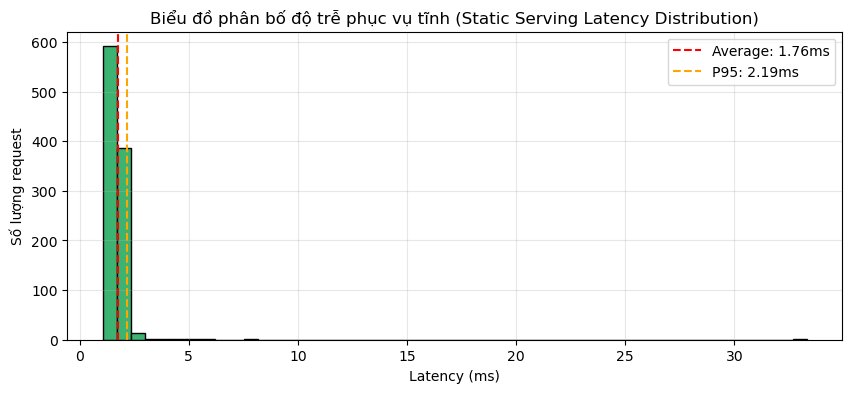

In [6]:
print("Đang đo hiệu năng xử lý trực tuyến (1000 requests ngẫu nhiên)...")
latencies = []

for i in range(1000):
    t_start = time.perf_counter()
    service.get_recommendations(user_id=old_user)
    t_end = time.perf_counter()
    latencies.append((t_end - t_start) * 1000.0)
    
avg_lat = np.mean(latencies)
p95_lat = np.percentile(latencies, 95)
p99_lat = np.percentile(latencies, 99)
max_lat = np.max(latencies)

print("-------------------------------------------")
print(f"Độ trễ trung bình (Average Latency): {avg_lat:.4f} ms")
print(f"Độ trễ 95% (P95 Latency):            {p95_lat:.4f} ms")
print(f"Độ trễ 99% (P99 Latency):            {p99_lat:.4f} ms")
print(f"Độ trễ tối đa (Max Latency):         {max_lat:.4f} ms")
print("-------------------------------------------")

# Vẽ đồ thị phân bố độ trễ
plt.figure(figsize=(10, 4))
plt.hist(latencies, bins=50, color='mediumseagreen', edgecolor='black')
plt.axvline(avg_lat, color='red', linestyle='--', label=f'Average: {avg_lat:.2f}ms')
plt.axvline(p95_lat, color='orange', linestyle='--', label=f'P95: {p95_lat:.2f}ms')
plt.title("Biểu đồ phân bố độ trễ phục vụ tĩnh (Static Serving Latency Distribution)")
plt.xlabel("Latency (ms)")
plt.ylabel("Số lượng request")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()